In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("hotel_bookings.csv")

In [3]:
df.shape

(119390, 33)

In [4]:
df.head()

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-15


In [5]:
df.tail()

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,119385,City Hotel,0,23,2017,August,35,30,2,5,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,06-09-17
119386,119386,City Hotel,0,102,2017,August,35,31,2,5,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,07-09-17
119387,119387,City Hotel,0,34,2017,August,35,31,2,5,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,07-09-17
119388,119388,City Hotel,0,109,2017,August,35,31,2,5,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,07-09-17
119389,119389,City Hotel,0,205,2017,August,35,29,2,7,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,07-09-17


In [6]:
df.sample(5)

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
22790,22790,Resort Hotel,0,27,2016,April,15,5,0,1,...,No Deposit,250.0,NaN,0,Transient,81.0,0,1,Check-Out,06-04-16
93573,93573,City Hotel,0,292,2016,July,30,21,0,2,...,No Deposit,6.0,NaN,0,Transient-Party,115.0,0,0,Check-Out,23-07-16
88079,88079,City Hotel,0,53,2016,April,18,28,0,3,...,No Deposit,9.0,NaN,0,Transient,120.0,0,1,Check-Out,01-05-16
13212,13212,Resort Hotel,1,8,2017,August,31,5,0,1,...,Non Refund,240.0,NaN,0,Transient,330.0,0,0,Canceled,01-08-17
8632,8632,Resort Hotel,1,393,2016,October,41,8,2,2,...,Non Refund,68.0,NaN,0,Transient,72.0,0,0,Canceled,17-12-15


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   index                           119390 non-null  int64  
 1   hotel                           119390 non-null  object 
 2   is_canceled                     119390 non-null  int64  
 3   lead_time                       119390 non-null  int64  
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  object 
 6   arrival_date_week_number        119390 non-null  int64  
 7   arrival_date_day_of_month       119390 non-null  int64  
 8   stays_in_weekend_nights         119390 non-null  int64  
 9   stays_in_week_nights            119390 non-null  int64  
 10  adults                          119390 non-null  int64  
 11  children                        119386 non-null  float64
 12  babies          

In [8]:
df.dtypes

index                               int64
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                      

In [10]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

company     112593
agent        16340
country        488
children         4
dtype: int64

In [11]:
df.duplicated().sum()

0

In [16]:
categorical_columns = df.select_dtypes(include="object").columns

In [17]:
categorical_columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

In [21]:
for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(20))


 hotel
City Hotel      79330
Resort Hotel    40060
Name: hotel, dtype: int64

 arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: arrival_date_month, dtype: int64

 meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: meal, dtype: int64

 country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
USA     2097
CHE     1730
CN      1279
AUT     1263
SWE     1024
CHN      999
POL      919
ISR      669
RUS      632
NOR      607
Name: country, dtype: int64

 market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: ma

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,119390.0,59694.500000,34465.068657,0.00,29847.25,59694.500,89541.75,119389.0
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.00,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.00,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.00,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.00,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.00,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.00,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.00,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.00,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.00,10.0


In [28]:
df[['adults', 'children', 'babies']].describe().T

,count,mean,std,min,25%,50%,75%,max
adults,119390.0,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0
children,119386.0,0.103890,0.398561,0.0,0.0,0.0,0.0,10.0
babies,119390.0,0.007949,0.097436,0.0,0.0,0.0,0.0,10.0


In [31]:
df[
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)
]

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,2224,Resort Hotel,0,1,2015,October,41,6,0,3,...,No Deposit,NaN,174.0,0,Transient-Party,0.00,0,0,Check-Out,06-10-15
2409,2409,Resort Hotel,0,0,2015,October,42,12,0,0,...,No Deposit,NaN,174.0,0,Transient,0.00,0,0,Check-Out,12-10-15
3181,3181,Resort Hotel,0,36,2015,November,47,20,1,2,...,No Deposit,38.0,NaN,0,Transient-Party,0.00,0,0,Check-Out,23-11-15
3684,3684,Resort Hotel,0,165,2015,December,53,30,1,4,...,No Deposit,308.0,NaN,122,Transient-Party,0.00,0,0,Check-Out,04-01-16
3708,3708,Resort Hotel,0,165,2015,December,53,30,2,4,...,No Deposit,308.0,NaN,122,Transient-Party,0.00,0,0,Check-Out,05-01-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,115029,City Hotel,0,107,2017,June,26,27,0,3,...,No Deposit,7.0,NaN,0,Transient,100.80,0,0,Check-Out,30-06-17
115091,115091,City Hotel,0,1,2017,June,26,30,0,1,...,No Deposit,NaN,NaN,0,Transient,0.00,1,1,Check-Out,01-07-17
116251,116251,City Hotel,0,44,2017,July,28,15,1,1,...,No Deposit,425.0,NaN,0,Transient,73.80,0,0,Check-Out,17-07-17
116534,116534,City Hotel,0,2,2017,July,28,15,2,5,...,No Deposit,9.0,NaN,0,Transient-Party,22.86,0,1,Check-Out,22-07-17


In [32]:
df[df['adr'] < 0]

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,14969,Resort Hotel,0,195,2017,March,10,5,4,6,...,No Deposit,273.0,NaN,0,Transient-Party,-6.38,0,0,Check-Out,15-03-17


In [33]:
df['children'].isna().sum()

4

In [34]:
df['children'] = df['children'].fillna(0)

In [36]:
df['country'].isna().sum()

488

In [37]:
df['country'] = df['country'].fillna('Unknown')

In [38]:
df['agent'].isna().sum()

16340

In [39]:
df['agent'] = df['agent'].fillna(0)

In [40]:
df['company'].isna().sum()

112593

In [41]:
df['company'] = df['company'].fillna(0)

In [42]:
for col in ['meal', 'market_segment', 'distribution_channel']:
    print(col)
    print(df[col].value_counts())

meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: meal, dtype: int64
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: market_segment, dtype: int64
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: distribution_channel, dtype: int64


In [43]:
df['meal'] = df['meal'].replace('Undefined', 'Unknown')
df['market_segment'] = df['market_segment'].replace('Undefined', 'Unknown')
df['distribution_channel'] = df['distribution_channel'].replace('Undefined', 'Unknown')

In [44]:
df['reservation_status_date'].dtype

dtype('O')

In [45]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'],format='%d-%m-%y',
    errors='coerce')

In [47]:
df['total_nights'] =(df['stays_in_weekend_nights'] + df['stays_in_week_nights'])

In [48]:
df['cancellation_status'] = df['is_canceled'].map({ 0: 'Not Canceled',1: 'Canceled'})

In [49]:
df['cancellation_status'] 

0         Not Canceled
1         Not Canceled
2         Not Canceled
3         Not Canceled
4         Not Canceled
              ...     
119385    Not Canceled
119386    Not Canceled
119387    Not Canceled
119388    Not Canceled
119389    Not Canceled
Name: cancellation_status, Length: 119390, dtype: object

In [50]:
df['estimated_revenue'] = (df['adr'] * df['total_nights'])#timated room revenue metric

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   index                           119390 non-null  int64         
 1   hotel                           119390 non-null  object        
 2   is_canceled                     119390 non-null  int64         
 3   lead_time                       119390 non-null  int64         
 4   arrival_date_year               119390 non-null  int64         
 5   arrival_date_month              119390 non-null  object        
 6   arrival_date_week_number        119390 non-null  int64         
 7   arrival_date_day_of_month       119390 non-null  int64         
 8   stays_in_weekend_nights         119390 non-null  int64         
 9   stays_in_week_nights            119390 non-null  int64         
 10  adults                          119390 non-null  int64  

In [52]:
df.isnull().sum().sort_values(ascending=False).head(10)

index                   0
hotel                   0
reserved_room_type      0
assigned_room_type      0
booking_changes         0
deposit_type            0
agent                   0
company                 0
days_in_waiting_list    0
customer_type           0
dtype: int64

In [54]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,119390.0,59694.500000,34465.068657,0.00,29847.25,59694.500,89541.75,119389.0
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.00,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.00,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.00,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.00,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.00,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.00,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.00,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.00,55.0
children,119390.0,0.103886,0.398555,0.00,0.00,0.000,0.00,10.0


In [55]:
df.duplicated().sum()

0

In [56]:
df['hotel'].value_counts()

City Hotel      79330
Resort Hotel    40060
Name: hotel, dtype: int64

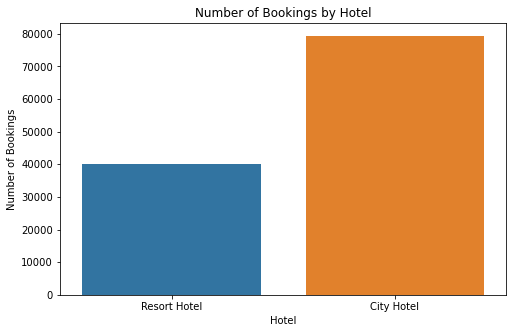

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='hotel')

plt.title('Number of Bookings by Hotel')
plt.xlabel('Hotel')
plt.ylabel('Number of Bookings')

plt.show()

In [64]:
#cancellation_rate
cancellation_rate = df['is_canceled'].mean() * 100

print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Cancellation Rate: 37.04%


In [65]:
cancellation_counts = df['cancellation_status'].value_counts()
cancellation_counts 

Not Canceled    75166
Canceled        44224
Name: cancellation_status, dtype: int64

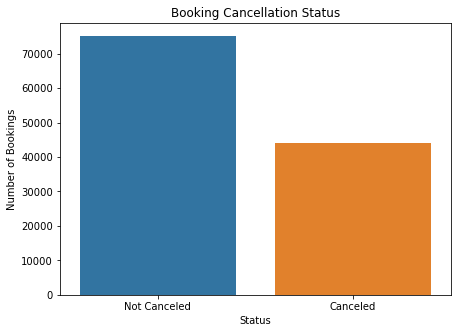

In [66]:
plt.figure(figsize=(7,5))
sns.barplot(x=cancellation_counts.index,y=cancellation_counts.values)

plt.title('Booking Cancellation Status')
plt.xlabel('Status')
plt.ylabel('Number of Bookings')

plt.show()

In [68]:
#Cancellation by Hotel
hotel_cancellation = ( df.groupby('hotel')['is_canceled'].mean().mul(100).reset_index())

hotel_cancellation

,hotel,is_canceled
0,City Hotel,41.726963
1,Resort Hotel,27.763355


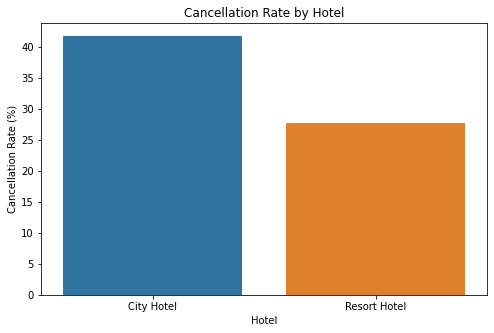

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(data=hotel_cancellation,x='hotel',y='is_canceled')

plt.title('Cancellation Rate by Hotel')
plt.xlabel('Hotel')
plt.ylabel('Cancellation Rate (%)')

plt.show()

In [71]:
#Bookings by Month
monthly_bookings = (df.groupby('arrival_date_month').size().reset_index(name='bookings'))
monthly_bookings

,arrival_date_month,bookings
0,April,11089
1,August,13877
2,December,6780
3,February,8068
4,January,5929
5,July,12661
6,June,10939
7,March,9794
8,May,11791
9,November,6794


In [72]:
months = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'],
    categories=months,
    ordered=True
)

In [74]:
monthly_bookings = (
    df.groupby('arrival_date_month', observed=True)
    .size()
    .reset_index(name='bookings')
)

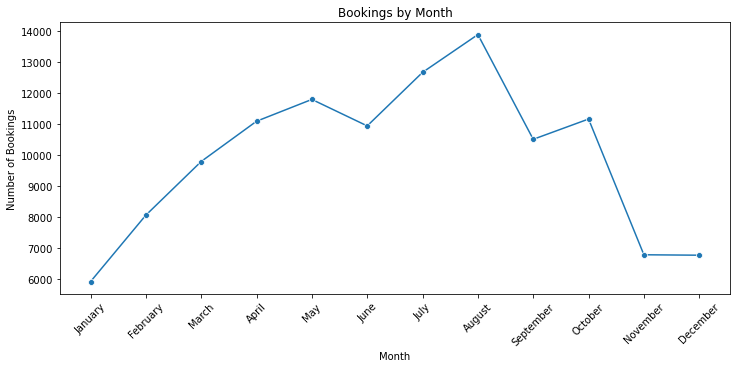

In [82]:
plt.figure(figsize=(12,5))

sns.lineplot(data=monthly_bookings, x='arrival_date_month',y='bookings', marker='o')

plt.xticks(rotation=45)
plt.title('Bookings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')

plt.show()

In [86]:
#adr_by_hotel
adr_by_hotel = ( df.groupby('hotel')['adr'].mean().reset_index())

adr_by_hotel

,hotel,adr
0,City Hotel,105.304465
1,Resort Hotel,94.952930


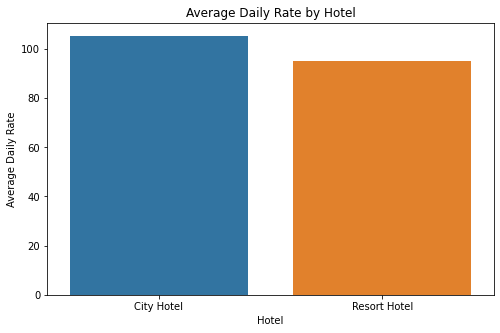

In [87]:
plt.figure(figsize=(8,5))

sns.barplot(data=adr_by_hotel,x='hotel',y='adr')

plt.title('Average Daily Rate by Hotel')
plt.xlabel('Hotel')
plt.ylabel('Average Daily Rate')

plt.show()

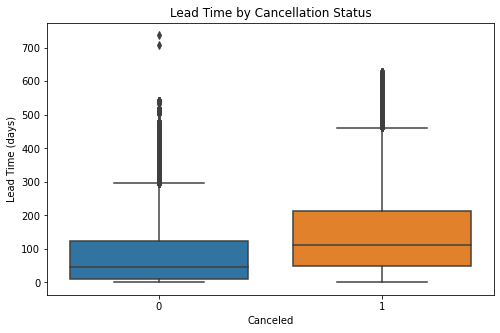

In [88]:
#Lead Time vs Cancellation
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x='is_canceled',y='lead_time')

plt.title('Lead Time by Cancellation Status')
plt.xlabel('Canceled')
plt.ylabel('Lead Time (days)')

plt.show()

In [90]:
#Market Segment
market = df['market_segment'].value_counts()
market

Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Unknown              2
Name: market_segment, dtype: int64

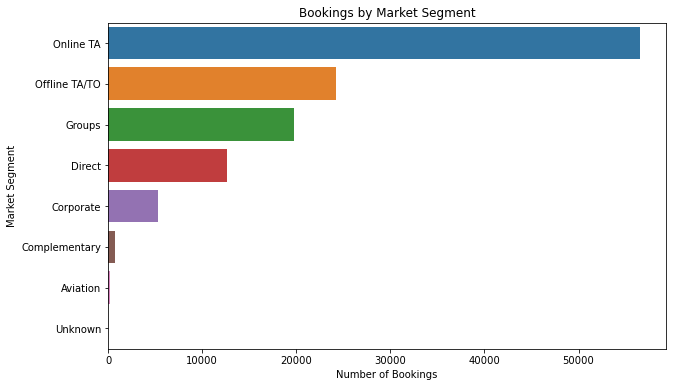

In [91]:
plt.figure(figsize=(10,6))

sns.barplot(x=market.values,y=market.index)

plt.title('Bookings by Market Segment')
plt.xlabel('Number of Bookings')
plt.ylabel('Market Segment')

plt.show()

In [92]:
#Cancellation Rate by Market Segment
segment_cancel = ( df.groupby('market_segment')['is_canceled'].mean().mul(100).sort_values(ascending=False))

segment_cancel

market_segment
Unknown          100.000000
Groups            61.062036
Online TA         36.721143
Offline TA/TO     34.316033
Aviation          21.940928
Corporate         18.734655
Direct            15.341901
Complementary     13.055182
Name: is_canceled, dtype: float64

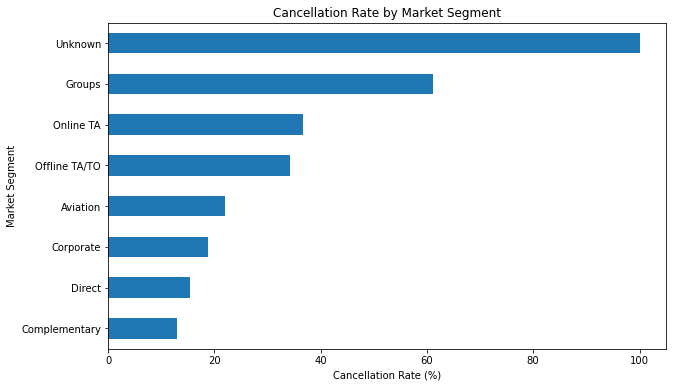

In [93]:
plt.figure(figsize=(10,6))

segment_cancel.sort_values().plot( kind='barh')

plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Market Segment')

plt.show()

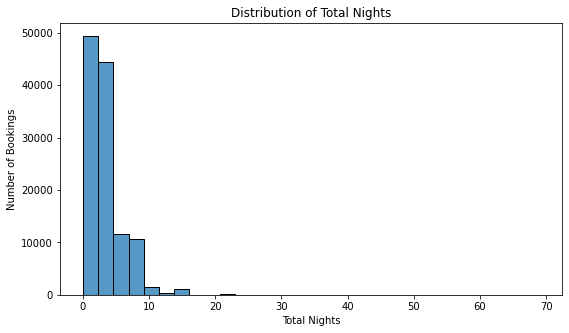

In [99]:
plt.figure(figsize=(9,5))

sns.histplot(data=df,x='total_nights',bins=30)

plt.title('Distribution of Total Nights')
plt.xlabel('Total Nights')
plt.ylabel('Number of Bookings')

plt.show()

In [100]:
df.to_csv("cleaned_hotel_bookings.csv", index=False)